<a href="https://colab.research.google.com/github/facuirib/Coder/blob/main/ProyectoDSParteI%2BBOSCH2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import Librerias#

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Carga DataFrame#

In [61]:
url = 'https://raw.githubusercontent.com/facuirib/Coder/refs/heads/main/credit_risk_dataset.csv'
df_loans = pd.read_csv(url)
print(df_loans.head())
#Lectura Data Frame#



   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


#Análisis DataFrame#

In [62]:
df_loans.shape
#Info del DataFrame#

(32581, 12)

In [63]:
df_loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


Rapidamente con info podemos observar que contamos con 12 columnas totales, detectando algunos posibles valores nulos en columna 3 y 7. Ademas observamos que tenemos tanto numero entero como decimal en el formato de algunas columnas, mas formato texto en otros.



In [64]:
df_loans.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


Conclusiones de DESCRIBE:
- person_age: Vemos que la edad maxima es de 144 años, lo que nos lleva a pensar que hay errores en los datos por lo que habria que revisar estos registros y tomar una decision.
-person_emp_length: Mismo casi de la edad. Hay registros con 123 de carrera laborar, lo cual son datos incorrectos.
- Hay mucha desviacion en Loan_Amnt y person_income lo que nos permite empezar a pensar que puede estar ocasionando esto y buscar correlaciones.
- Loan_Status: Binario. Nos dice que tenemos un True-False. Lo podemos entender como Aprobado / No Aprobado.

In [65]:
df_loans.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [66]:
df_loans.tail()


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


Con Head y Tail podemos tener una vista previa y estructura de los datos. Nos lleva a pensar posibles relaciones a revisar para enteder comportamientos y crear hipotesis/preguntas.

- Cuales la variable con mayor correlacion con el Riesgo Crediticio?
- Hay una correlacion entre EDAD y el Riesgo del Credito?
- Aumenta el interes del prestamo si hay menor ingreso?
- Infiere el hecho de poseer una casa para que te aprueben el credito?

#Análisis y Decision sobre Valores Nulos#

In [67]:
df_loans.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [68]:
a=(3116+985)/32581
print(a)


0.12587090635646542


Podemos observar valores nulos en emp_lenght y en la tasa de interes. Teniendo registros por un total de 32581 y siendo 3116 + 895 posibles registros con valores nulos, si eliminamos los mismos corremos riesgo de perder 12,5% de los datos.
Para evitar perderlos (tampoco es un % tan alto del DataSet) reemplazaremos ambos registros por la media de cada variable.

In [69]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
df_loans['person_emp_length'] = imputer.fit_transform(df_loans[['person_emp_length']])
df_loans['loan_int_rate'] = imputer.fit_transform(df_loans[['loan_int_rate']])
df_loans.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


#Análisis y Decision sobre Outliers#

<Axes: xlabel='person_age'>

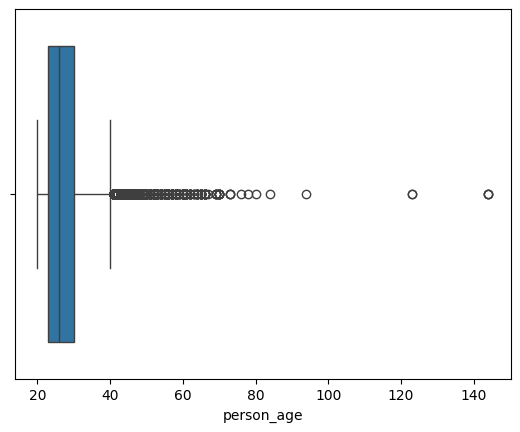

In [70]:
sns.boxplot(x=df_loans['person_age'])


Aqui ya observamos dos outliers de edad mayor a 100 años y procedemos a eliminarlos.

In [91]:
df_loans = df_loans[df_loans['person_age'] <= 70]
df_loans = df_loans.reset_index(drop=True)


<Axes: xlabel='person_emp_length'>

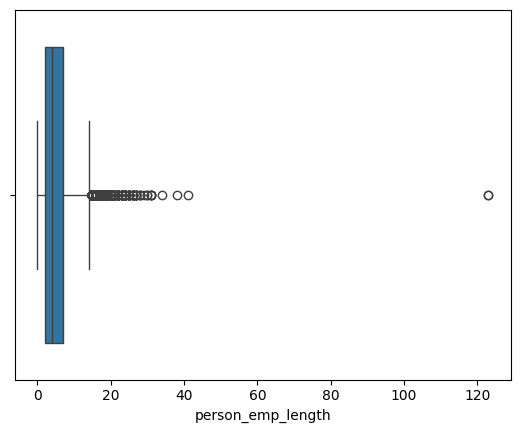

In [72]:
sns.boxplot(x=df_loans['person_emp_length'])


Aqui ya observamos un outliers de lenght mayor a 100 y procedemos a eliminarlo.



In [73]:
df_loans = df_loans[df_loans['person_emp_length'] <= 100]
df_loans = df_loans.reset_index(drop=True)

<Axes: xlabel='person_income'>

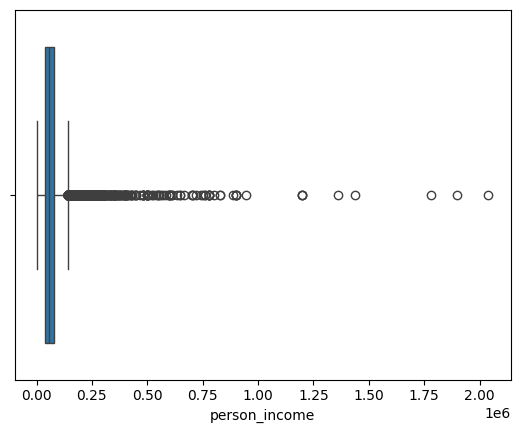

In [57]:
sns.boxplot(x=df_loans['person_income'])

In [76]:
Q1 = df_loans['person_income'].quantile(0.25)
Q3 = df_loans['person_income'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df_loans = df_loans[(df_loans['person_income'] >= limite_inferior) & (df_loans['person_income'] <= limite_superior)]
df_loans = df_loans.reset_index(drop=True)




<Axes: xlabel='loan_amnt'>

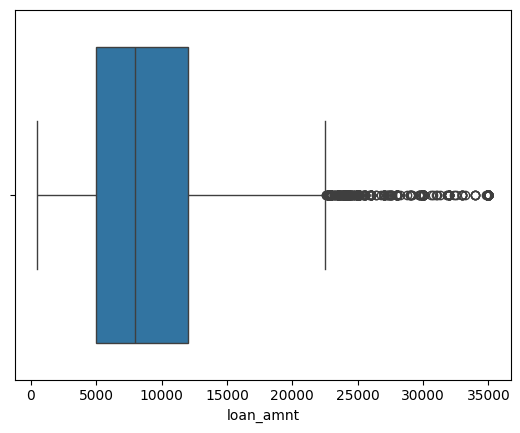

In [80]:
sns.boxplot(x=df_loans['loan_amnt'])

#Duplicados#

In [82]:
duplicados = df_loans.duplicated()
num_duplicados = duplicados.sum()
print(f"Numero de duplicados: {num_duplicados}")

Numero de duplicados: 159


In [83]:
df_loans = df_loans.drop_duplicates()


#Hipotesis

-Hay una correlacion entre EDAD y el Riesgo del Credito?

-Aumenta el interes del prestamo si hay menor ingreso? y el interes respecto al grade?

-Infiere el hecho de poseer una casa con la nota del credito?

-Que grado de credito tiene mas probabilidad de entrar en default?

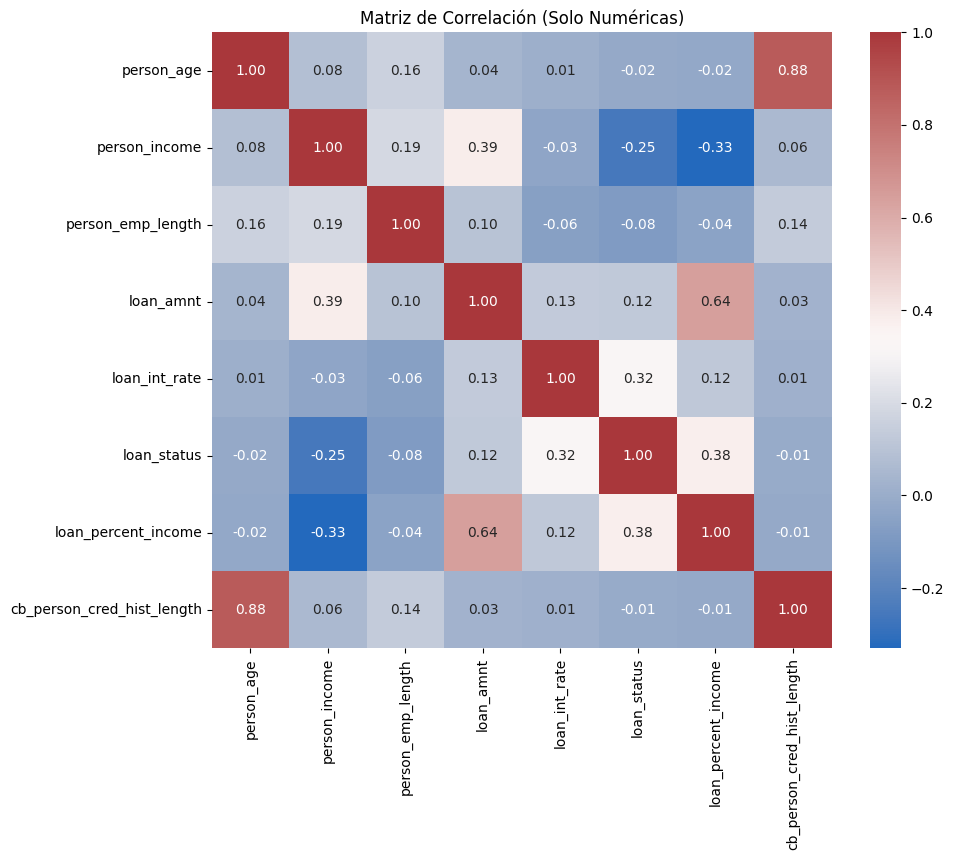

In [112]:
numeric_df = df_loans.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='vlag', fmt=".2f")
plt.title('Matriz de Correlación (Solo Numéricas)')
plt.show()

Con la matriz de correlacion podemos detectar las siguientes correlaciones entre variables:
- Person_age se relaciona fuertemente con person_cred_hist_lengh pero no es una relacion que nos importe en nuestras hipotesis
- loan_amt y loan_percent_income tambien se relacionan bastante, lo que indicaria que el monto del credito dependera del ingreso del solicitante.

In [106]:
bins = [0, 25, 35, 45, 55, 65, float('inf')]
labels = ['<25', '25-35', '35-45', '45-55', '55-65', '>65']
df_loans['age_group'] = pd.cut(df_loans['person_age'], bins=bins, labels=labels, right=False)


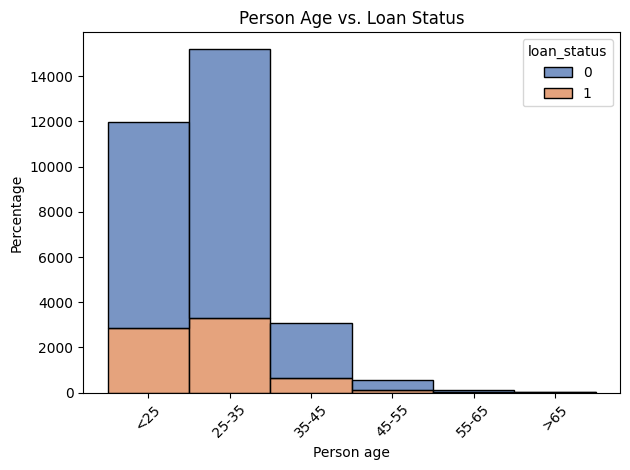

In [121]:
sns.histplot(data=df_loans, x="age_group", hue="loan_status", multiple="stack", palette="deep")
plt.title("Person Age vs. Loan Status")
plt.xlabel("Person age")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

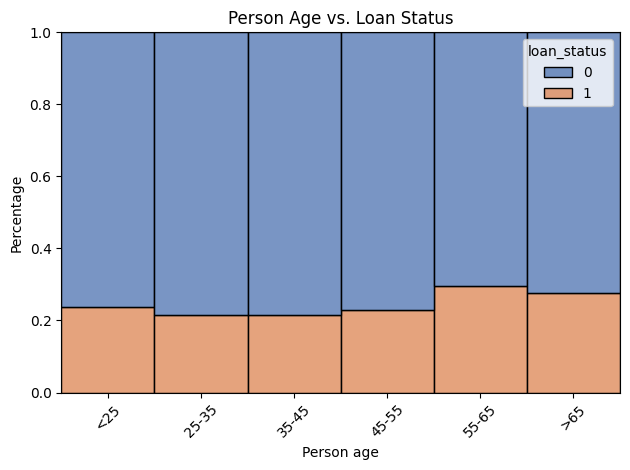

In [122]:
sns.histplot(data=df_loans, x="age_group", hue="loan_status", multiple="fill", stat="density", palette="deep") # Changed parameters here

plt.title("Person Age vs. Loan Status")
plt.xlabel("Person age")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Hipotesis 1:**
*-Hay una correlacion entre EDAD y el Riesgo del Credito?*


Este grafico nos permite responder la primera hipotesis. Diriamos que hay un poco mas de riesgo de defaul del credito para los mayores a 55 años pero no mucho mas que el resto de rangos de edad. Podemos decir que el riesgo de default esta en torno a un 25%.

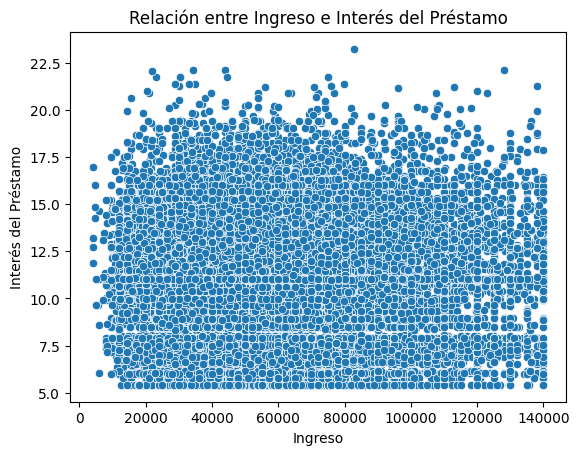

In [124]:
sns.scatterplot(data=df_loans, x="person_income", y="loan_int_rate")
plt.title("Relación entre Ingreso e Interés del Préstamo")
plt.xlabel("Ingreso")
plt.ylabel("Interés del Préstamo")
plt.show()

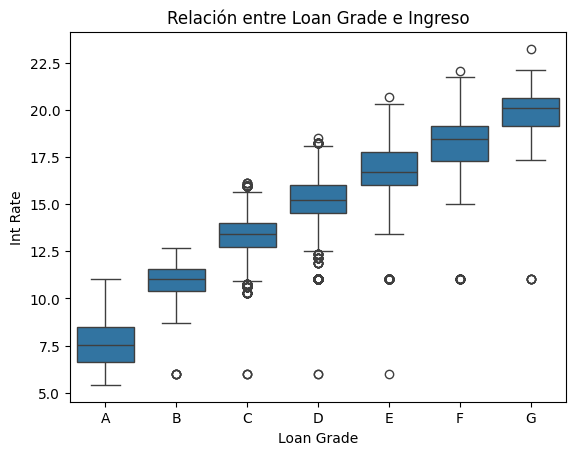

In [130]:
loan_grade_order = sorted(df_loans['loan_grade'].unique())
sns.boxplot(data=df_loans, x="loan_grade", y="loan_int_rate", order=loan_grade_order)
plt.title("Relación entre Loan Grade e Ingreso")
plt.xlabel("Loan Grade")
plt.ylabel("Int Rate")
plt.show()

**Hipotesis 2:** *-Aumenta el interes del prestamo si hay menor ingreso? y el interes respecto al grade?*

Con estos dos graficos podemos decir que no hay un relacion marcada entre el interes del prestamo y el ingreso del solicitante. Pero si vemos una relacion muy marcada entre Interes y Grade. A medida que el grade del loan es peor aumenta el Interes.

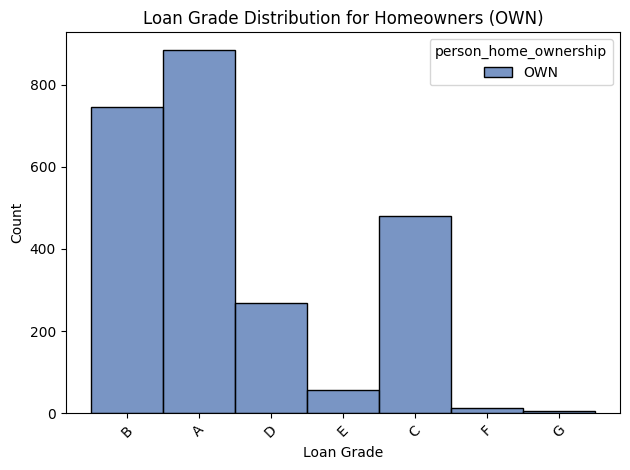

In [135]:
filtered_df = df_loans[df_loans['person_home_ownership'] == 'OWN']
sns.histplot(data=filtered_df, x="loan_grade", hue="person_home_ownership", multiple="stack", palette="deep")
plt.title("Loan Grade Distribution for Homeowners (OWN)")
plt.xlabel("Loan Grade")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Hipotesis 3:**
*-Infiere el hecho de poseer una casa con la nota del credito?*

Si, infiere bastante. En el grafico podemos ver que los poseedores de casa se suelen encontrar en las categorias A y B en su mayoria, lo cual sugiere que disponer de una casa provoca una mejor nota crediticia.

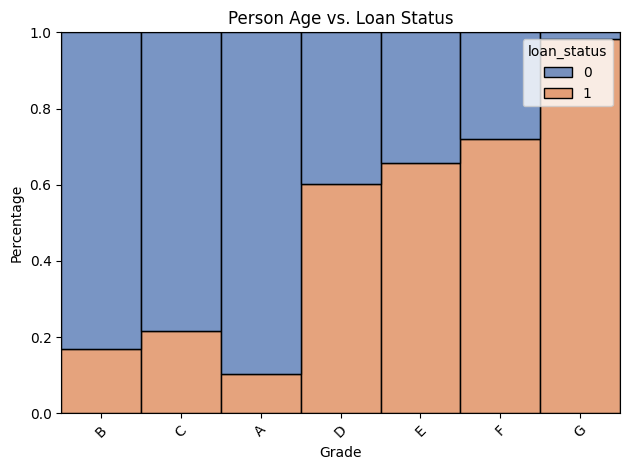

In [141]:
sns.histplot(data=df_loans, x="loan_grade", hue="loan_status", multiple="fill", stat="density", palette="deep")

plt.title("Person Age vs. Loan Status")
plt.xlabel("Grade")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Hipotesis 4: -Que grado de credito tiene mas probabilidad de entrar en default?

Claramente las peores notas de credito son las que mas probabilidad tienen de entrar en default.

G:Cerca del 100%
F:70%
E:65%
D:60%
C:20%
B:15%
A:10%